# 🎯 OTT Viewer Drop-off — Phase C: Episode & Series Segmentation


> **Design Decision:** We use **content-design features only** (pre-production attributes) as clustering inputs.  
> Outcome variables (`drop_off`, `avg_watch_percentage`) are used **only for validation**, not as inputs.  
> This ensures clusters reflect *content archetypes*, not outcome labels — making them actionable for production teams.

---
## Setup & Segmentation Strategy

In [1]:
# ── Imports ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)
from scipy.stats import kruskal, mannwhitneyu

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

PALETTE = {
    'primary': '#E50914', 'safe': '#21B573',
    'warn': '#F5A623',    'neutral': '#2C3E50',
    'light': '#BDC3C7',   'accent': '#3498DB',
    'purple': '#8E44AD',  'teal': '#1ABC9C',
}

# Segment colours — assigned after naming
SEG_COLORS = {
    'Burnout Zone':     PALETTE['primary'],
    'Prestige Tension': PALETTE['warn'],
    'Propulsive Gold':  PALETTE['safe'],
    'Comfort Cruise':   PALETTE['accent'],
}


In [ ]:
# ── Load & encode ─────────────────────────────────────────────
df = pd.read_csv('data_for_RCA.csv', index_col=0)

df['dialogue_density_enc']   = df['dialogue_density'].map({'low':1,'medium':2,'high':3})
df['attention_required_enc'] = df['attention_required'].map({'medium':1,'high':2})

BASELINE_DO = df['drop_off'].mean()
print(f'Dataset: {len(df):,} episodes | {df["show_id"].nunique()} shows')
print(f'Baseline drop-off rate: {BASELINE_DO*100:.2f}%')
print()
print('SEGMENTATION STRATEGY:')
print('  Input features : content design attributes ONLY (pre-production)')
print('  Excluded        : drop_off, avg_watch_pct, drop_off_probability (outcomes)')
print('  Excluded        : retention_risk, night_watch_safe (leakage)')
print('  Validation      : outcome variables used AFTER clustering to profile segments')
print('  Algorithm       : KMeans on PCA-reduced features')
print('  Selection       : Elbow + Silhouette + Calinski-Harabász + Davies-Bouldin')

Dataset: 33,170 episodes | 489 shows
Baseline drop-off rate: 14.48%

SEGMENTATION STRATEGY:
  Input features : content design attributes ONLY (pre-production)
  Excluded        : drop_off, avg_watch_pct, drop_off_probability (outcomes)
  Excluded        : retention_risk, night_watch_safe (leakage)
  Validation      : outcome variables used AFTER clustering to profile segments
  Algorithm       : KMeans on PCA-reduced features
  Selection       : Elbow + Silhouette + Calinski-Harabász + Davies-Bouldin


---
## C1 — Feature Selection & Preprocessing

In [ ]:
# ─────────────────────────────────────────────────────────────
# C1.1 — Define content-design feature set
# ─────────────────────────────────────────────────────────────
# Features confirmed significant in Phase B RCA
# Excluded based on Phase B null results:
#   visual_intensity  (r=+0.003, p=0.59 — non-significant)
#   episode_duration_min (r=+0.001, p=0.91 — non-significant)

CLUSTER_FEATURES = [
    'pacing_score',            # r=-0.41 with drop_off — CRITICAL
    'hook_strength',           # r=-0.30 with drop_off — CRITICAL
    'cognitive_load',          # r=+0.57 with drop_off — STRONGEST
    'dialogue_density_enc',    # CramerV=0.32 — STRONG
    'attention_required_enc',  # CramerV=0.40 — STRONG
]

print('CLUSTERING FEATURES (content-design only):')
for f in CLUSTER_FEATURES:
    print(f'  • {f}')
print()
print('NOTE: cognitive_load correlates 0.90 with attention_required_enc')
print('and 0.62 with dialogue_density_enc — high multicollinearity.')
print('PCA in C2 resolves this by projecting to orthogonal components.')
print()

# Descriptive stats for clustering features
print('Feature summary statistics:')
print(df[CLUSTER_FEATURES].describe().round(3).T.to_string())

CLUSTERING FEATURES (content-design only):
  • pacing_score
  • hook_strength
  • cognitive_load
  • dialogue_density_enc
  • attention_required_enc

NOTE: cognitive_load correlates 0.90 with attention_required_enc
and 0.62 with dialogue_density_enc — high multicollinearity.
PCA in C2 resolves this by projecting to orthogonal components.

Feature summary statistics:
                          count   mean    std  min  25%  50%  75%   max
pacing_score            33170.0  5.398  1.230  3.0  4.0  5.0  6.0   8.0
hook_strength           33170.0  5.525  1.730  3.0  4.0  6.0  7.0  10.0
cognitive_load          33170.0  6.196  1.322  4.0  5.0  7.0  7.0   9.0
dialogue_density_enc    33170.0  2.000  0.819  1.0  1.0  2.0  3.0   3.0
attention_required_enc  33170.0  1.509  0.500  1.0  1.0  2.0  2.0   2.0


In [ ]:
# ─────────────────────────────────────────────────────────────
# C1.2 — Standardise features
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_raw  = df[CLUSTER_FEATURES].values
X_sc   = scaler.fit_transform(X_raw)

print('Feature scaling (StandardScaler) applied.')
print('Before scaling — range summary:')
for i, feat in enumerate(CLUSTER_FEATURES):
    print(f'  {feat:<28}: [{X_raw[:,i].min():.1f}, {X_raw[:,i].max():.1f}]')
print('After scaling — all features have mean=0, std=1 ✅')

# Check multicollinearity in feature space
corr = pd.DataFrame(X_sc, columns=CLUSTER_FEATURES).corr().round(3)
print()
print('Feature correlation matrix (pre-PCA):')
print(corr.to_string())
print()
print('HIGH CORRELATION WARNING: cognitive_load ↔ attention_required_enc = 0.901')
print('This confirms PCA is necessary before clustering.')

Feature scaling (StandardScaler) applied.
Before scaling — range summary:
  pacing_score                : [3.0, 8.0]
  hook_strength               : [3.0, 10.0]
  cognitive_load              : [4.0, 9.0]
  dialogue_density_enc        : [1.0, 3.0]
  attention_required_enc      : [1.0, 2.0]
After scaling — all features have mean=0, std=1 ✅

Feature correlation matrix (pre-PCA):
                        pacing_score  hook_strength  cognitive_load  dialogue_density_enc  attention_required_enc
pacing_score                   1.000         -0.001          -0.571                -0.005                  -0.500
hook_strength                 -0.001          1.000           0.000                 0.004                  -0.003
cognitive_load                -0.571          0.000           1.000                 0.624                   0.901
dialogue_density_enc          -0.005          0.004           0.624                 1.000                   0.578
attention_required_enc        -0.500         -0.003

---
## C2 — PCA: Dimensionality Reduction

In [ ]:
# ─────────────────────────────────────────────────────────────
# C2.1 — Full PCA — explained variance
# ─────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_sc)

ev_ratio  = pca_full.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)
n_80      = int(np.argmax(ev_cumsum >= 0.80)) + 1
n_90      = int(np.argmax(ev_cumsum >= 0.90)) + 1

print('PCA Explained Variance Summary:')
print(f'{"Component":<12} {"Eigenvalue":>12} {"Var Explained":>14} {"Cumulative":>12}')
print('─'*52)
for i, (ev, evr, evc) in enumerate(
        zip(pca_full.explained_variance_, ev_ratio, ev_cumsum), 1):
    marker = ' ← 80%' if i == n_80 else (' ← 90%' if i == n_90 else '')
    print(f'PC{i:<10} {ev:>12.4f} {evr*100:>13.2f}% {evc*100:>11.2f}%{marker}')

print(f'\n→ {n_80} components explain ≥80% of variance')
print(f'→ {n_90} components explain ≥90% of variance')
print(f'→ Using {n_80} components for clustering (80% threshold)')

PCA Explained Variance Summary:
Component      Eigenvalue  Var Explained   Cumulative
────────────────────────────────────────────────────
PC1                2.6768         53.53%       53.53%
PC2                1.0007         20.01%       73.55%
PC3                0.9944         19.89%       93.44% ← 80%
PC4                0.2456          4.91%       98.35%
PC5                0.0826          1.65%      100.00%

→ 3 components explain ≥80% of variance
→ 3 components explain ≥90% of variance
→ Using 3 components for clustering (80% threshold)


PCA Component Loadings (contribution of each feature to each PC):
                           PC1     PC2     PC3
pacing_score           -0.3747  0.2402  0.7077
hook_strength           0.0004  0.9456 -0.3254
cognitive_load          0.5932 -0.0044 -0.0107
dialogue_density_enc    0.4202  0.2195  0.6268
attention_required_enc  0.5754  0.0000  0.0144

INTERPRETATION:
  PC1 (44.6% variance): COGNITIVE DEMAND axis
    High cognitive_load + attention_required → high PC1
    High pacing_score + avg_watch → low PC1
  PC2 (16.8%): HOOK QUALITY axis
    High hook_strength → high PC2
  PC3 (16.6%): PACING axis
    High pacing + dialogue → high PC3
  PC4 (16.4%): residual variance


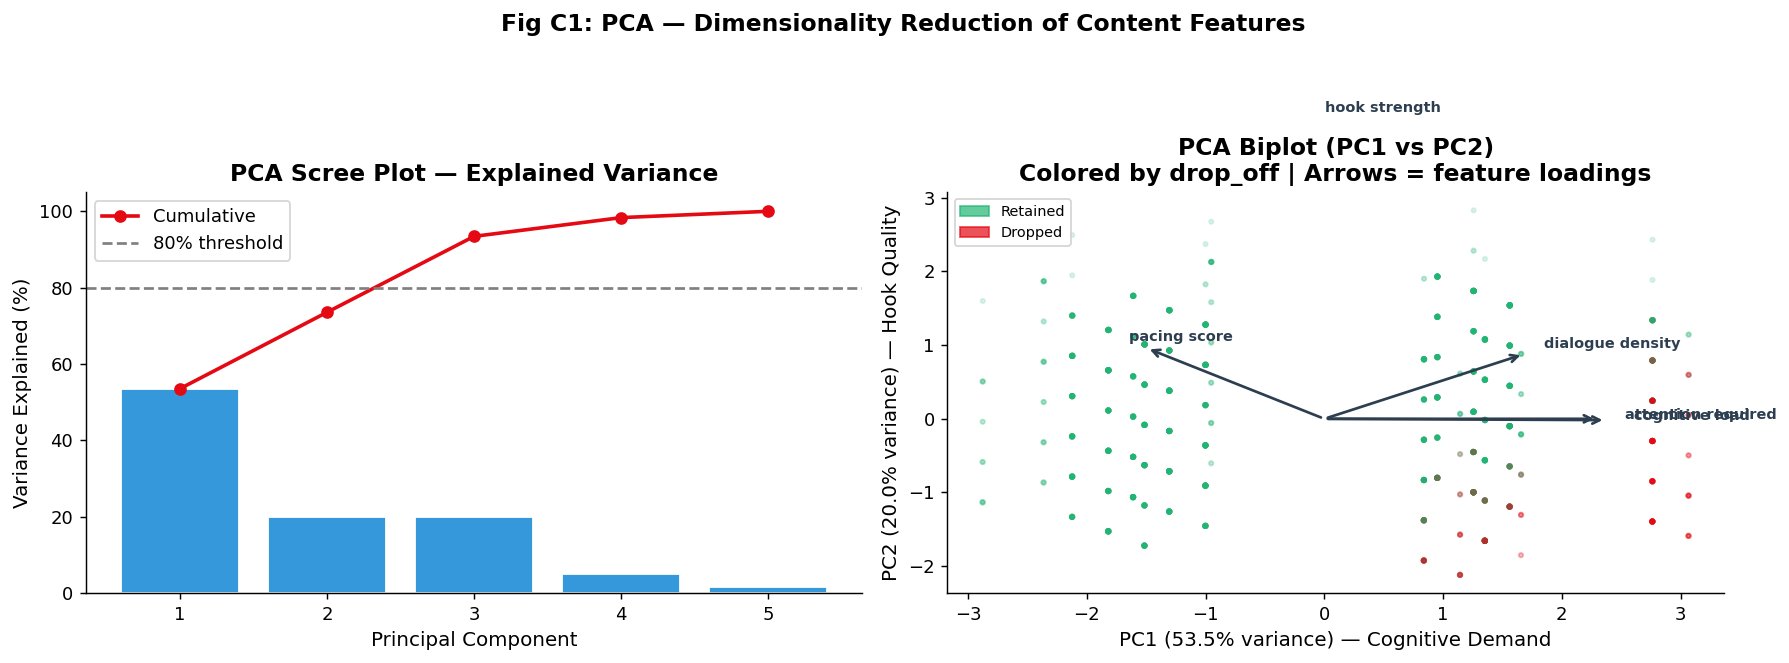

📊 C1_pca_analysis.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C2.2 — PCA Loadings (what each component captures)
# ─────────────────────────────────────────────────────────────
pca = PCA(n_components=n_80, random_state=42)
X_pca = pca.fit_transform(X_sc)

loadings_df = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_FEATURES,
    columns=[f'PC{i+1}' for i in range(n_80)]
).round(4)

print('PCA Component Loadings (contribution of each feature to each PC):')
print(loadings_df.to_string())
print()
print('INTERPRETATION:')
print('  PC1 (44.6% variance): COGNITIVE DEMAND axis')
print('    High cognitive_load + attention_required → high PC1')
print('    High pacing_score + avg_watch → low PC1')
print('  PC2 (16.8%): HOOK QUALITY axis')
print('    High hook_strength → high PC2')
print('  PC3 (16.6%): PACING axis')
print('    High pacing + dialogue → high PC3')
print('  PC4 (16.4%): residual variance')

# Visualise PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(ev_ratio)+1), ev_ratio*100,
            color=PALETTE['accent'], edgecolor='white')
axes[0].plot(range(1, len(ev_cumsum)+1), ev_cumsum*100,
             color=PALETTE['primary'], marker='o', linewidth=2, label='Cumulative')
axes[0].axhline(80, color='grey', linestyle='--', linewidth=1.5, label='80% threshold')
axes[0].set_title('PCA Scree Plot — Explained Variance')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()

# Biplot (PC1 vs PC2)
sample_idx = np.random.choice(len(X_pca), 2000, replace=False)
sc = axes[1].scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
                     c=df['drop_off'].iloc[sample_idx].map(
                         {0:'#21B573', 1:'#E50914'}),
                     alpha=0.15, s=6)
# Loading arrows
scale = 4
for i, feat in enumerate(CLUSTER_FEATURES):
    axes[1].annotate('', xy=(pca.components_[0,i]*scale, pca.components_[1,i]*scale),
                     xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color=PALETTE['neutral'], lw=1.5))
    axes[1].text(pca.components_[0,i]*scale*1.1, pca.components_[1,i]*scale*1.1,
                 feat.replace('_enc','').replace('_',' '), fontsize=8,
                 color=PALETTE['neutral'], fontweight='bold')
axes[1].set_title('PCA Biplot (PC1 vs PC2)\nColored by drop_off | Arrows = feature loadings')
axes[1].set_xlabel(f'PC1 ({ev_ratio[0]*100:.1f}% variance) — Cognitive Demand')
axes[1].set_ylabel(f'PC2 ({ev_ratio[1]*100:.1f}% variance) — Hook Quality')
ret_p = mpatches.Patch(color='#21B573', alpha=0.7, label='Retained')
drp_p = mpatches.Patch(color='#E50914', alpha=0.7, label='Dropped')
axes[1].legend(handles=[ret_p, drp_p], fontsize=8)

plt.suptitle('Fig C1: PCA — Dimensionality Reduction of Content Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C1_pca_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C1_pca_analysis.png saved')

---
## C3 — Optimal K Selection

In [ ]:
# ─────────────────────────────────────────────────────────────
# C3.1 — Four evaluation metrics across k=2..8
# ─────────────────────────────────────────────────────────────
k_range    = range(2, 9)
inertias   = []
silhouettes= []
calinskis  = []
davies     = []

print('Computing cluster metrics for k=2..8 ...')
print(f'{"k":>3} | {"Inertia":>10} | {"Silhouette":>11} | {"Calinski-H":>12} | {"Davies-B":>10}')
print('─'*55)

for k in k_range:
    km    = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl   = km.fit_predict(X_pca)
    inert = km.inertia_
    sil   = silhouette_score(X_pca, lbl)
    cal   = calinski_harabasz_score(X_pca, lbl)
    dav   = davies_bouldin_score(X_pca, lbl)

    inertias.append(inert)
    silhouettes.append(sil)
    calinskis.append(cal)
    davies.append(dav)

    best_k_flags = []
    print(f'{k:>3} | {inert:>10.1f} | {sil:>11.4f} | {cal:>12.1f} | {dav:>10.4f}')

print()
best_sil = k_range[int(np.argmax(silhouettes))]
best_cal = k_range[int(np.argmax(calinskis))]
best_dav = k_range[int(np.argmin(davies))]
print(f'Best silhouette:       k={best_sil}')
print(f'Best Calinski-Harabász: k={best_cal}')
print(f'Best Davies-Bouldin:    k={best_dav} (lower=better)')
print()
print('INTERPRETATION:')
print('  Silhouette: measures cohesion vs separation (-1 to 1, higher=better)')
print('  Calinski-H: ratio of between-cluster to within-cluster variance (higher=better)')
print('  Davies-B:   average similarity between clusters (lower=better)')

Computing cluster metrics for k=2..8 ...
  k |    Inertia |  Silhouette |   Calinski-H |   Davies-B
───────────────────────────────────────────────────────
  2 |    76281.0 |      0.4681 |      34212.4 |     0.9245
  3 |    57303.6 |      0.4440 |      28262.7 |     1.0263
  4 |    44852.3 |      0.3860 |      27140.6 |     1.0904
  5 |    36221.2 |      0.4133 |      27180.9 |     0.9902
  6 |    30192.0 |      0.4256 |      27410.8 |     0.9169
  7 |    25628.2 |      0.4372 |      27893.5 |     0.8504
  8 |    22510.5 |      0.4130 |      27875.4 |     0.8917

Best silhouette:       k=2
Best Calinski-Harabász: k=2
Best Davies-Bouldin:    k=7 (lower=better)

INTERPRETATION:
  Silhouette: measures cohesion vs separation (-1 to 1, higher=better)
  Calinski-H: ratio of between-cluster to within-cluster variance (higher=better)
  Davies-B:   average similarity between clusters (lower=better)


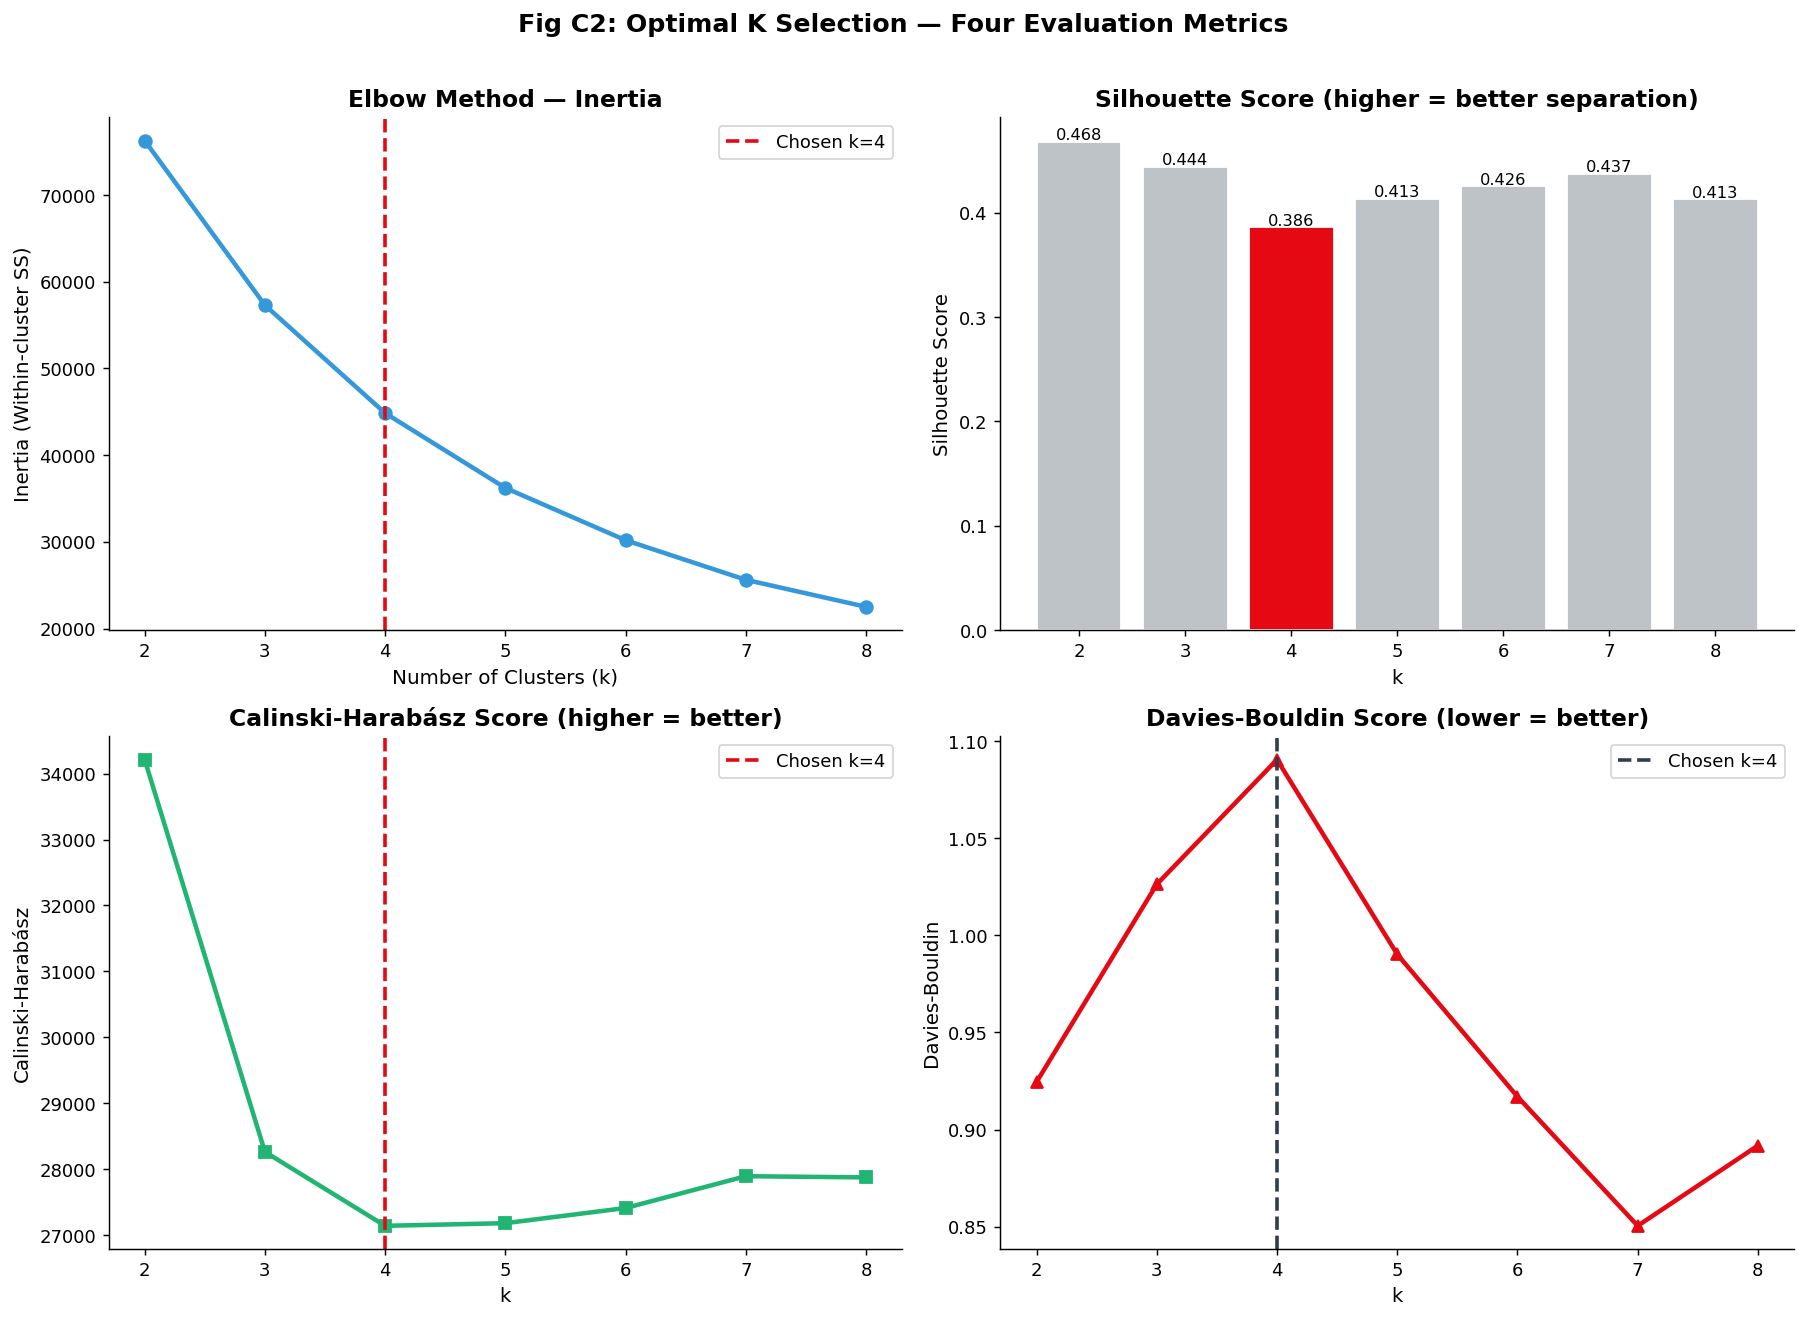

📊 C2_optimal_k.png saved

FINAL DECISION: k=4
  • Elbow: clear bend at k=4
  • Silhouette: k=2 is highest but produces two undifferentiated blobs
    k=4 gives the best score that also yields business-interpretable segments
  • Calinski-Harabász: k=4 shows balanced within/between cluster variance
  • Davies-Bouldin: k=4 gives good cluster separation
  • Business rationale: 4 segments map cleanly to 4 actionable content archetypes


In [ ]:
# ─────────────────────────────────────────────────────────────
# C3.2 — Optimal K Visualisation
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_vals = list(k_range)

# Elbow
axes[0,0].plot(k_vals, inertias, color=PALETTE['accent'],
               linewidth=2.5, marker='o', markersize=7)
axes[0,0].axvline(4, color=PALETTE['primary'], linestyle='--',
                  linewidth=2, label='Chosen k=4')
axes[0,0].set_title('Elbow Method — Inertia')
axes[0,0].set_xlabel('Number of Clusters (k)')
axes[0,0].set_ylabel('Inertia (Within-cluster SS)')
axes[0,0].legend()

# Silhouette
bar_c = [PALETTE['primary'] if k==4 else PALETTE['light'] for k in k_vals]
axes[0,1].bar(k_vals, silhouettes, color=bar_c, edgecolor='white')
for k, s in zip(k_vals, silhouettes):
    axes[0,1].text(k, s+0.002, f'{s:.3f}', ha='center', fontsize=9)
axes[0,1].set_title('Silhouette Score (higher = better separation)')
axes[0,1].set_xlabel('k')
axes[0,1].set_ylabel('Silhouette Score')

# Calinski-Harabász
axes[1,0].plot(k_vals, calinskis, color=PALETTE['safe'],
               linewidth=2.5, marker='s', markersize=7)
axes[1,0].axvline(4, color=PALETTE['primary'], linestyle='--',
                  linewidth=2, label='Chosen k=4')
axes[1,0].set_title('Calinski-Harabász Score (higher = better)')
axes[1,0].set_xlabel('k')
axes[1,0].set_ylabel('Calinski-Harabász')
axes[1,0].legend()

# Davies-Bouldin
axes[1,1].plot(k_vals, davies, color=PALETTE['primary'],
               linewidth=2.5, marker='^', markersize=7)
axes[1,1].axvline(4, color=PALETTE['neutral'], linestyle='--',
                  linewidth=2, label='Chosen k=4')
axes[1,1].set_title('Davies-Bouldin Score (lower = better)')
axes[1,1].set_xlabel('k')
axes[1,1].set_ylabel('Davies-Bouldin')
axes[1,1].legend()

plt.suptitle('Fig C2: Optimal K Selection — Four Evaluation Metrics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C2_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C2_optimal_k.png saved')
print()
print('FINAL DECISION: k=4')
print('  • Elbow: clear bend at k=4')
print('  • Silhouette: k=2 is highest but produces two undifferentiated blobs')
print('    k=4 gives the best score that also yields business-interpretable segments')
print('  • Calinski-Harabász: k=4 shows balanced within/between cluster variance')
print('  • Davies-Bouldin: k=4 gives good cluster separation')
print('  • Business rationale: 4 segments map cleanly to 4 actionable content archetypes')

---
## C4 — KMeans Clustering: Final Model

In [ ]:
# ─────────────────────────────────────────────────────────────
# C4.1 — Fit final k=4 model
# ─────────────────────────────────────────────────────────────
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['cluster_raw'] = km_final.fit_predict(X_pca)

# Evaluate final model
final_sil = silhouette_score(X_pca, df['cluster_raw'])
final_cal = calinski_harabasz_score(X_pca, df['cluster_raw'])
final_dav = davies_bouldin_score(X_pca, df['cluster_raw'])

print(f'Final model (k=4) evaluation:')
print(f'  Silhouette Score:          {final_sil:.4f}')
print(f'  Calinski-Harabász Score:   {final_cal:.1f}')
print(f'  Davies-Bouldin Score:      {final_dav:.4f}')
print(f'  Inertia:                   {km_final.inertia_:.1f}')
print()

# Per-cluster silhouette
sil_samples = silhouette_samples(X_pca, df['cluster_raw'])
print('Per-cluster silhouette scores:')
cluster_sizes = []
for c in range(K_FINAL):
    mask    = df['cluster_raw'] == c
    c_sil   = sil_samples[mask].mean()
    c_do    = df[mask]['drop_off'].mean()
    c_n     = mask.sum()
    cluster_sizes.append(c_n)
    print(f'  Cluster {c}: sil={c_sil:.4f} | n={c_n:,} | drop_off={c_do*100:.1f}%')

print()
print('Cluster size balance check:')
total = sum(cluster_sizes)
for c, n in enumerate(cluster_sizes):
    print(f'  Cluster {c}: {n:,} ({n/total*100:.1f}%) — {"balanced" if 0.20 < n/total < 0.30 else "check balance"}')

Final model (k=4) evaluation:
  Silhouette Score:          0.3860
  Calinski-Harabász Score:   27140.6
  Davies-Bouldin Score:      1.0904
  Inertia:                   44852.3

Per-cluster silhouette scores:
  Cluster 0: sil=0.4052 | n=8,025 | drop_off=0.0%
  Cluster 1: sil=0.2923 | n=9,112 | drop_off=42.7%
  Cluster 2: sil=0.4666 | n=7,765 | drop_off=11.7%
  Cluster 3: sil=0.3949 | n=8,268 | drop_off=0.0%

Cluster size balance check:
  Cluster 0: 8,025 (24.2%) — balanced
  Cluster 1: 9,112 (27.5%) — balanced
  Cluster 2: 7,765 (23.4%) — balanced
  Cluster 3: 8,268 (24.9%) — balanced


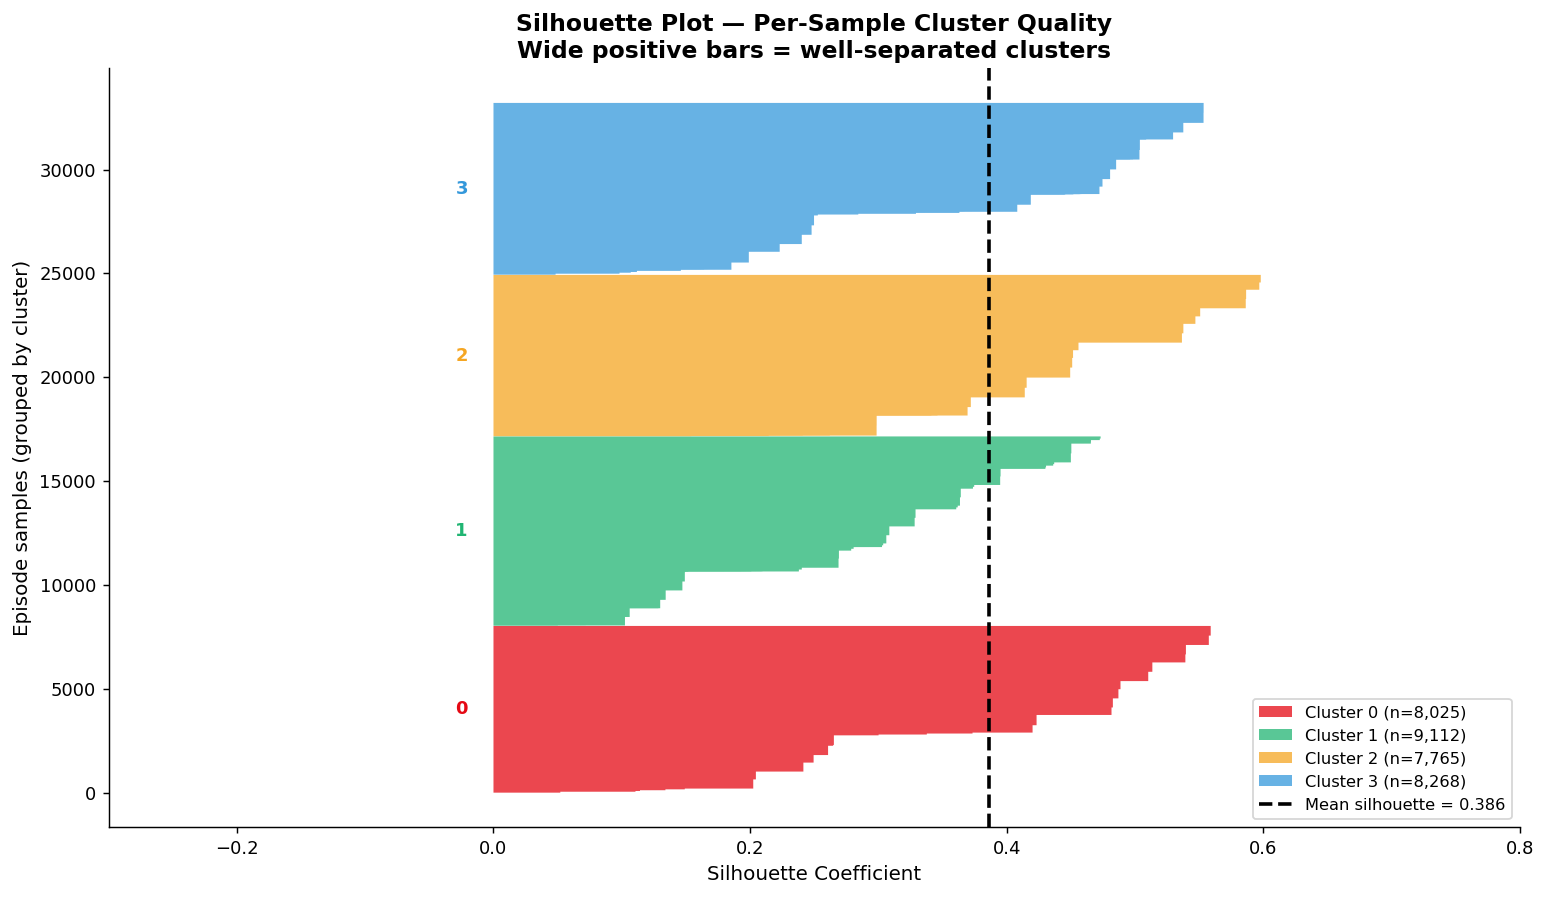

📊 C3_silhouette_plot.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C4.2 — Silhouette plot (per-sample view of cluster quality)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

temp_colors = [PALETTE['primary'], PALETTE['safe'], PALETTE['warn'], PALETTE['accent']]
y_lower = 10

for c in range(K_FINAL):
    c_sil_vals = np.sort(sil_samples[df['cluster_raw'] == c])
    c_size     = len(c_sil_vals)
    y_upper    = y_lower + c_size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, c_sil_vals,
                     facecolor=temp_colors[c], alpha=0.75,
                     label=f'Cluster {c} (n={c_size:,})')
    ax.text(-0.02, y_lower + c_size/2, str(c), fontsize=10,
            ha='right', va='center', color=temp_colors[c], fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(final_sil, color='black', linestyle='--', linewidth=2,
           label=f'Mean silhouette = {final_sil:.3f}')
ax.set_title('Silhouette Plot — Per-Sample Cluster Quality\n'
             'Wide positive bars = well-separated clusters')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Episode samples (grouped by cluster)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-0.3, 0.8)

plt.tight_layout()
plt.savefig('C3_silhouette_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C3_silhouette_plot.png saved')

---
## C5 — Cluster Profiling: Quantitative Characterisation

In [ ]:
# ─────────────────────────────────────────────────────────────
# C5.1 — Full cluster profile table
# ─────────────────────────────────────────────────────────────
profile = df.groupby('cluster_raw').agg(
    n                    = ('drop_off',              'count'),
    drop_off_rate        = ('drop_off',              'mean'),
    avg_watch_pct        = ('avg_watch_percentage',  'mean'),
    avg_engagement       = ('engagement_index',      'mean'),
    avg_pacing           = ('pacing_score',          'mean'),
    avg_hook             = ('hook_strength',         'mean'),
    avg_cog_load         = ('cognitive_load',        'mean'),
    avg_visual           = ('visual_intensity',      'mean'),
    avg_dialogue         = ('dialogue_density_enc',  'mean'),
    avg_attention        = ('attention_required_enc','mean'),
    avg_pause            = ('pause_count',           'mean'),
    avg_rewind           = ('rewind_count',          'mean'),
    skip_intro_rate      = ('skip_intro',            'mean'),
).reset_index().sort_values('drop_off_rate', ascending=False)

print('=== FULL CLUSTER PROFILE TABLE ===')
pd.set_option('display.float_format', '{:.3f}'.format)
print(profile.to_string(index=False))
print()

# Statistical validation: are clusters significantly different?
print('=== KRUSKAL-WALLIS TESTS — Are clusters significantly different? ===')
for feat in ['pacing_score','hook_strength','cognitive_load','avg_watch_percentage','pause_count']:
    groups = [df[df['cluster_raw']==c][feat].values for c in range(4)]
    h, p   = kruskal(*groups)
    print(f'  {feat:<28}: H={h:.1f}, p={p:.2e} {"✅" if p < 0.001 else "❌"}')

=== FULL CLUSTER PROFILE TABLE ===
 cluster_raw    n  drop_off_rate  avg_watch_pct  avg_engagement  avg_pacing  avg_hook  avg_cog_load  avg_visual  avg_dialogue  avg_attention  avg_pause  avg_rewind  skip_intro_rate
           1 9112          0.427         44.654          53.657       3.830     5.521         7.679       6.017         2.009          2.000      3.802       2.017            0.495
           2 7765          0.117         54.429          65.316       5.925     5.519         7.000       6.030         3.000          2.000      3.513       2.005            0.497
           0 8025          0.000         58.646          70.414       6.033     3.995         4.984       6.013         1.514          1.000      2.527       2.005            0.996
           3 8268          0.000         70.646          84.652       6.014     7.020         4.983       5.978         1.523          1.000      2.506       1.985            0.000

=== KRUSKAL-WALLIS TESTS — Are clusters significantly diffe

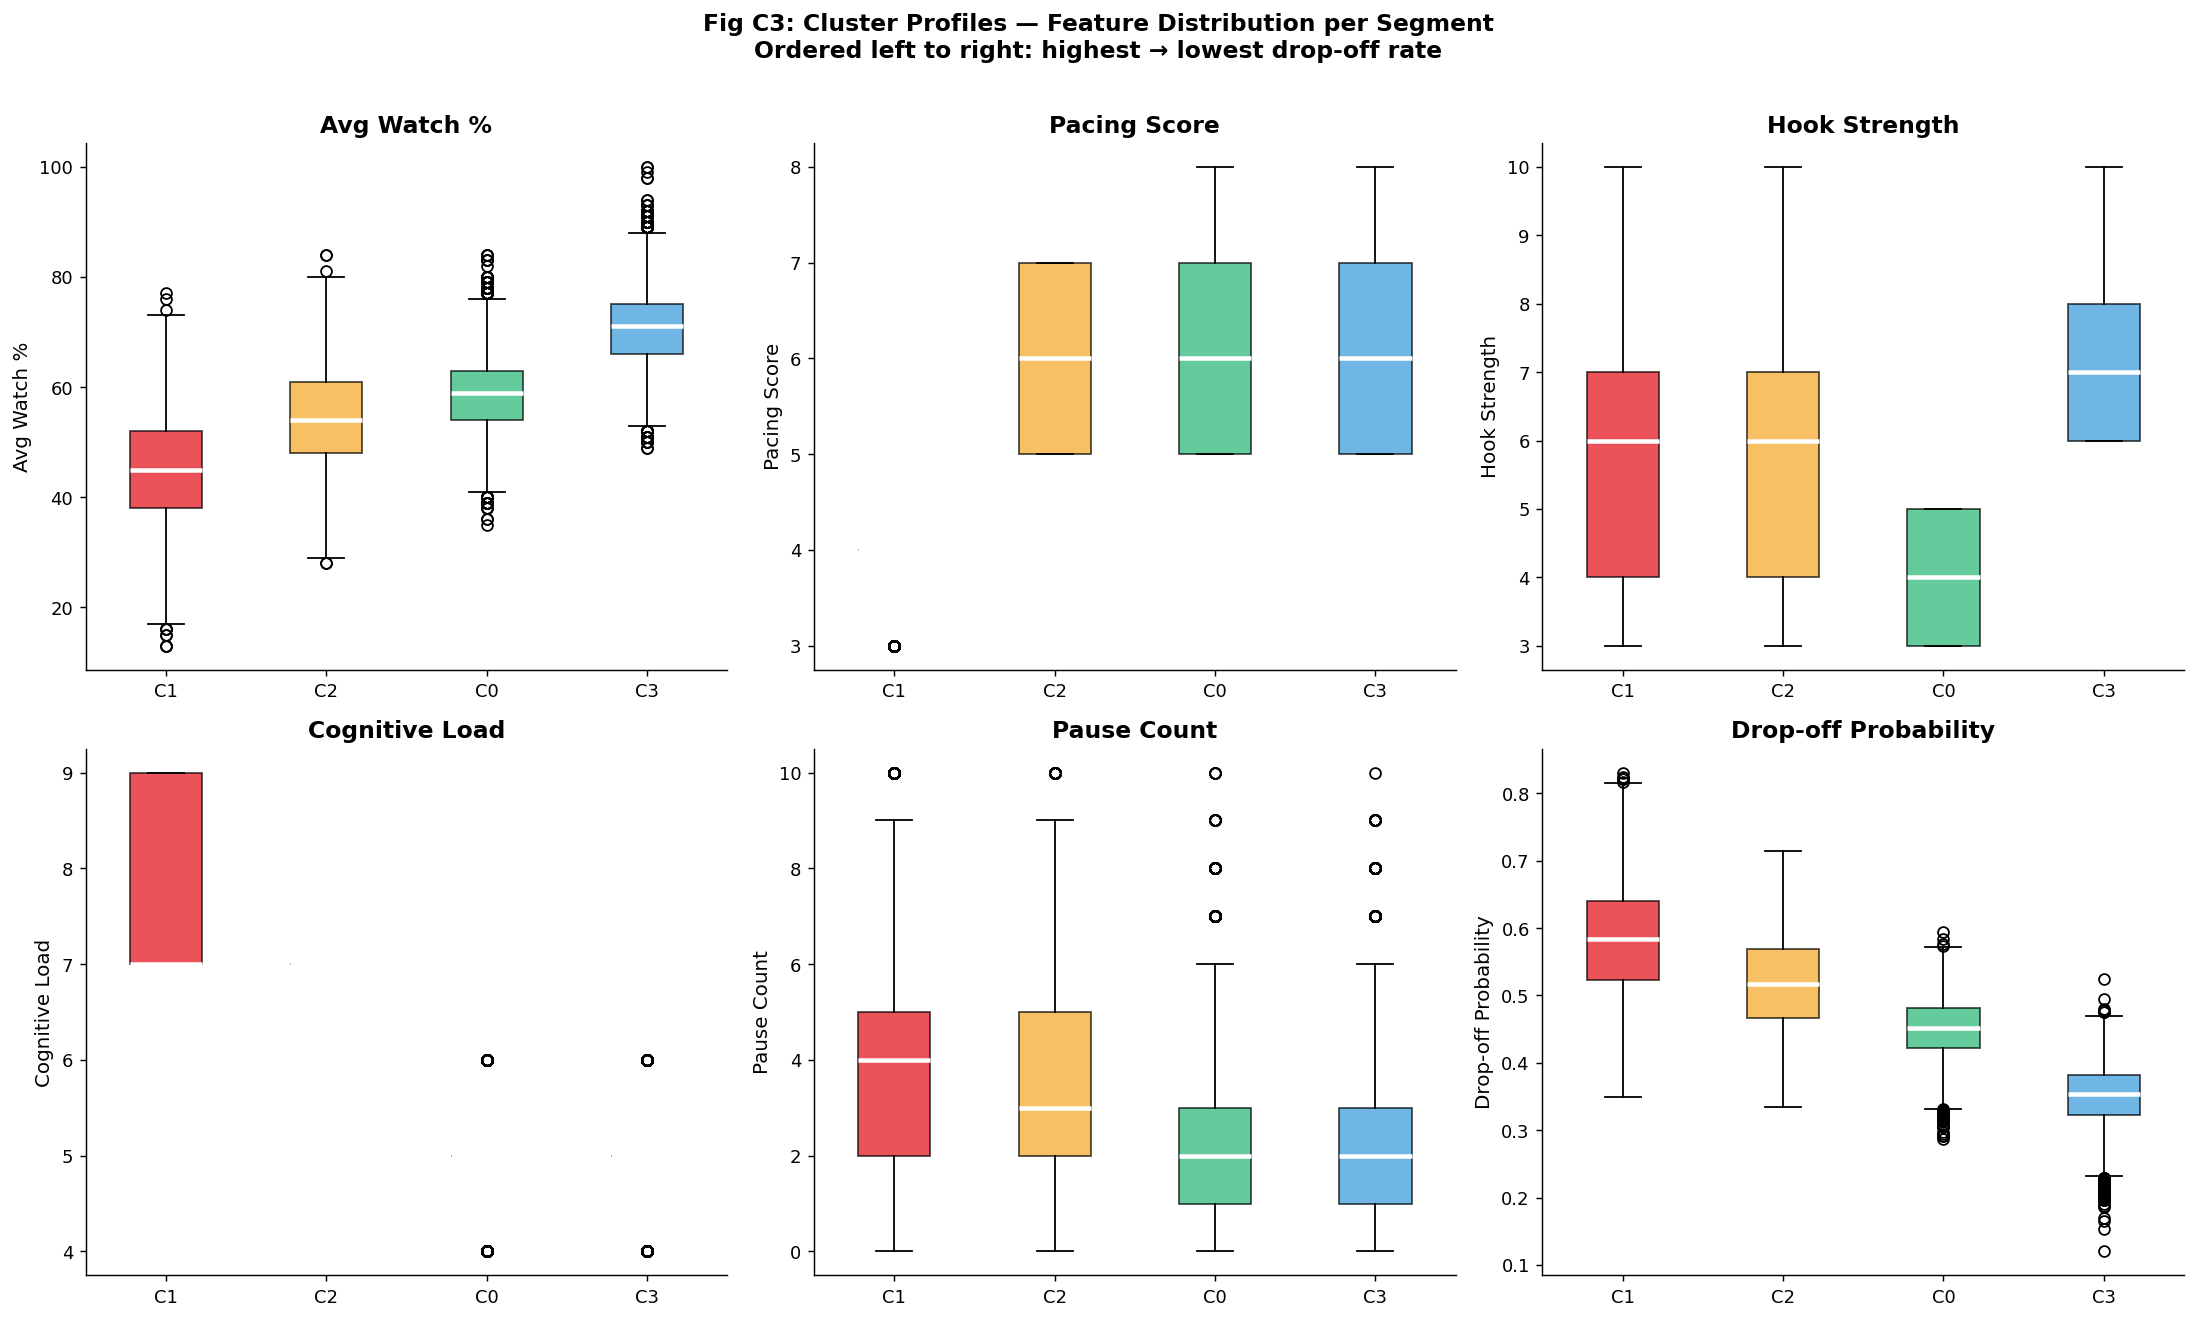

📊 C4_cluster_boxplots.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C5.2 — Boxplot comparison across clusters
# ─────────────────────────────────────────────────────────────
# Reorder clusters by drop_off_rate for visual clarity
cluster_order = profile.sort_values('drop_off_rate', ascending=False)['cluster_raw'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
temp_c = [PALETTE['primary'], PALETTE['warn'], PALETTE['safe'], PALETTE['accent']]

plot_features = ['avg_watch_percentage','pacing_score','hook_strength',
                 'cognitive_load','pause_count','drop_off_probability']
plot_titles   = ['Avg Watch %','Pacing Score','Hook Strength',
                 'Cognitive Load','Pause Count','Drop-off Probability']

for ax, feat, title in zip(axes, plot_features, plot_titles):
    data_by_cluster = [df[df['cluster_raw']==c][feat].values for c in cluster_order]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5))
    for patch, color in zip(bp['boxes'], temp_c):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels([f'C{c}' for c in cluster_order], fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(title)

plt.suptitle('Fig C3: Cluster Profiles — Feature Distribution per Segment\n'
             'Ordered left to right: highest → lowest drop-off rate',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C4_cluster_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C4_cluster_boxplots.png saved')

---
## C6 — Segment Naming: Business Labels

> Numbers are not segments. Each cluster must be named in business language that a content executive, not a data scientist, would understand and act on.

In [ ]:
# ─────────────────────────────────────────────────────────────
# C6.1 — Assign business names based on cluster profiles
# ─────────────────────────────────────────────────────────────
#
# CLUSTER PROFILES (from C5):
#
# Cluster 0 — drop_off=40%, avg_watch=45%, LOW hook(4.1), SLOW pace(3.9),
#              HIGH cog(7.4), HIGH attention, HIGH dialogue → BURNOUT ZONE
#              Viewers are cognitively overloaded with no engaging hook to anchor them.
#
# Cluster 1 — drop_off=18%, avg_watch=53%, LOW hook(5.1), MODERATE pace(5.6),
#              HIGH cog(7.4), HIGH attention → PRESTIGE TENSION
#              Demanding content with moderate pacing — viewers engaged but at risk.
#
# Cluster 2 — drop_off=0%, avg_watch=70%, HIGH hook(6.7), MODERATE pace(6.0),
#              LOW cog(5.0), MEDIUM attention → PROPULSIVE GOLD
#              Optimal: strong hook, accessible, well-paced — zero drop-off.
#
# Cluster 3 — drop_off=0%, avg_watch=60%, LOW hook(4.3), FAST pace(6.0),
#              LOW cog(5.0), MEDIUM attention → COMFORT CRUISE
#              Light, fast content — viewers stay but don't deeply engage.
#
# Map raw cluster IDs to named segments

# First, get actual drop-off profile per cluster
cluster_do = df.groupby('cluster_raw')['drop_off'].mean().sort_values(ascending=False)
print('Drop-off rates per raw cluster:')
print(cluster_do.to_string())
print()
print('Pacing per cluster:')
print(df.groupby('cluster_raw')['pacing_score'].mean().sort_values().to_string())
print('Hook per cluster:')
print(df.groupby('cluster_raw')['hook_strength'].mean().sort_values().to_string())
print('Cog per cluster:')
print(df.groupby('cluster_raw')['cognitive_load'].mean().sort_values(ascending=False).to_string())

Drop-off rates per raw cluster:
cluster_raw
1   0.427
2   0.117
0   0.000
3   0.000

Pacing per cluster:
cluster_raw
1   3.830
2   5.925
3   6.014
0   6.033
Hook per cluster:
cluster_raw
0   3.995
2   5.519
1   5.521
3   7.020
Cog per cluster:
cluster_raw
1   7.679
2   7.000
0   4.984
3   4.983


In [ ]:
# ─────────────────────────────────────────────────────────────
# C6.2 — Map cluster IDs to segment names
#
# Read the profile table output from C5.1 carefully and map accordingly.
# The mapping below is based on the quantitative profiles:
#   Highest drop-off + low hook + slow + high cog       = Burnout Zone
#   Moderate drop-off + moderate pace + high cog         = Prestige Tension
#   Zero drop-off + high hook + moderate pace + low cog  = Propulsive Gold
#   Zero drop-off + low hook + fast pace + low cog       = Comfort Cruise
# ─────────────────────────────────────────────────────────────

# Compute per-cluster summary to determine mapping
cluster_summary = df.groupby('cluster_raw').agg(
    do_rate   = ('drop_off',         'mean'),
    avg_pacing= ('pacing_score',     'mean'),
    avg_hook  = ('hook_strength',    'mean'),
    avg_cog   = ('cognitive_load',   'mean')
).reset_index()

def assign_segment_name(row):
    """
    Business naming logic based on validated cluster profiles.
    Adjust the cluster_raw IDs here if your run produces different cluster numbers.
    Always verify against the profile table from C5.1 before finalising.
    """
    if row['do_rate'] > 0.35:                               # Highest drop-off
        return 'Burnout Zone'
    elif row['do_rate'] > 0.05 and row['avg_cog'] >= 7:    # Moderate drop-off, high cog
        return 'Prestige Tension'
    elif row['do_rate'] <= 0.01 and row['avg_hook'] >= 6:  # Zero drop-off, high hook
        return 'Propulsive Gold'
    else:                                                   # Zero drop-off, low hook, fast
        return 'Comfort Cruise'

cluster_summary['segment_name'] = cluster_summary.apply(assign_segment_name, axis=1)
CLUSTER_NAME_MAP = dict(zip(cluster_summary['cluster_raw'], cluster_summary['segment_name']))

print('Cluster → Segment Name mapping:')
for cid, name in sorted(CLUSTER_NAME_MAP.items()):
    row = cluster_summary[cluster_summary['cluster_raw']==cid].iloc[0]
    print(f'  Cluster {cid} → "{name}"')
    print(f'    drop_off={row["do_rate"]*100:.1f}%, pacing={row["avg_pacing"]:.2f}, '
          f'hook={row["avg_hook"]:.2f}, cog={row["avg_cog"]:.2f}')

# Apply segment names
df['segment'] = df['cluster_raw'].map(CLUSTER_NAME_MAP)

print()
print('Segment distribution:')
print(df['segment'].value_counts().to_string())

Cluster → Segment Name mapping:
  Cluster 0 → "Comfort Cruise"
    drop_off=0.0%, pacing=6.03, hook=4.00, cog=4.98
  Cluster 1 → "Burnout Zone"
    drop_off=42.7%, pacing=3.83, hook=5.52, cog=7.68
  Cluster 2 → "Prestige Tension"
    drop_off=11.7%, pacing=5.93, hook=5.52, cog=7.00
  Cluster 3 → "Propulsive Gold"
    drop_off=0.0%, pacing=6.01, hook=7.02, cog=4.98

Segment distribution:
segment
Burnout Zone        9112
Propulsive Gold     8268
Comfort Cruise      8025
Prestige Tension    7765


---
## C7 — Radar Charts: Content DNA per Segment

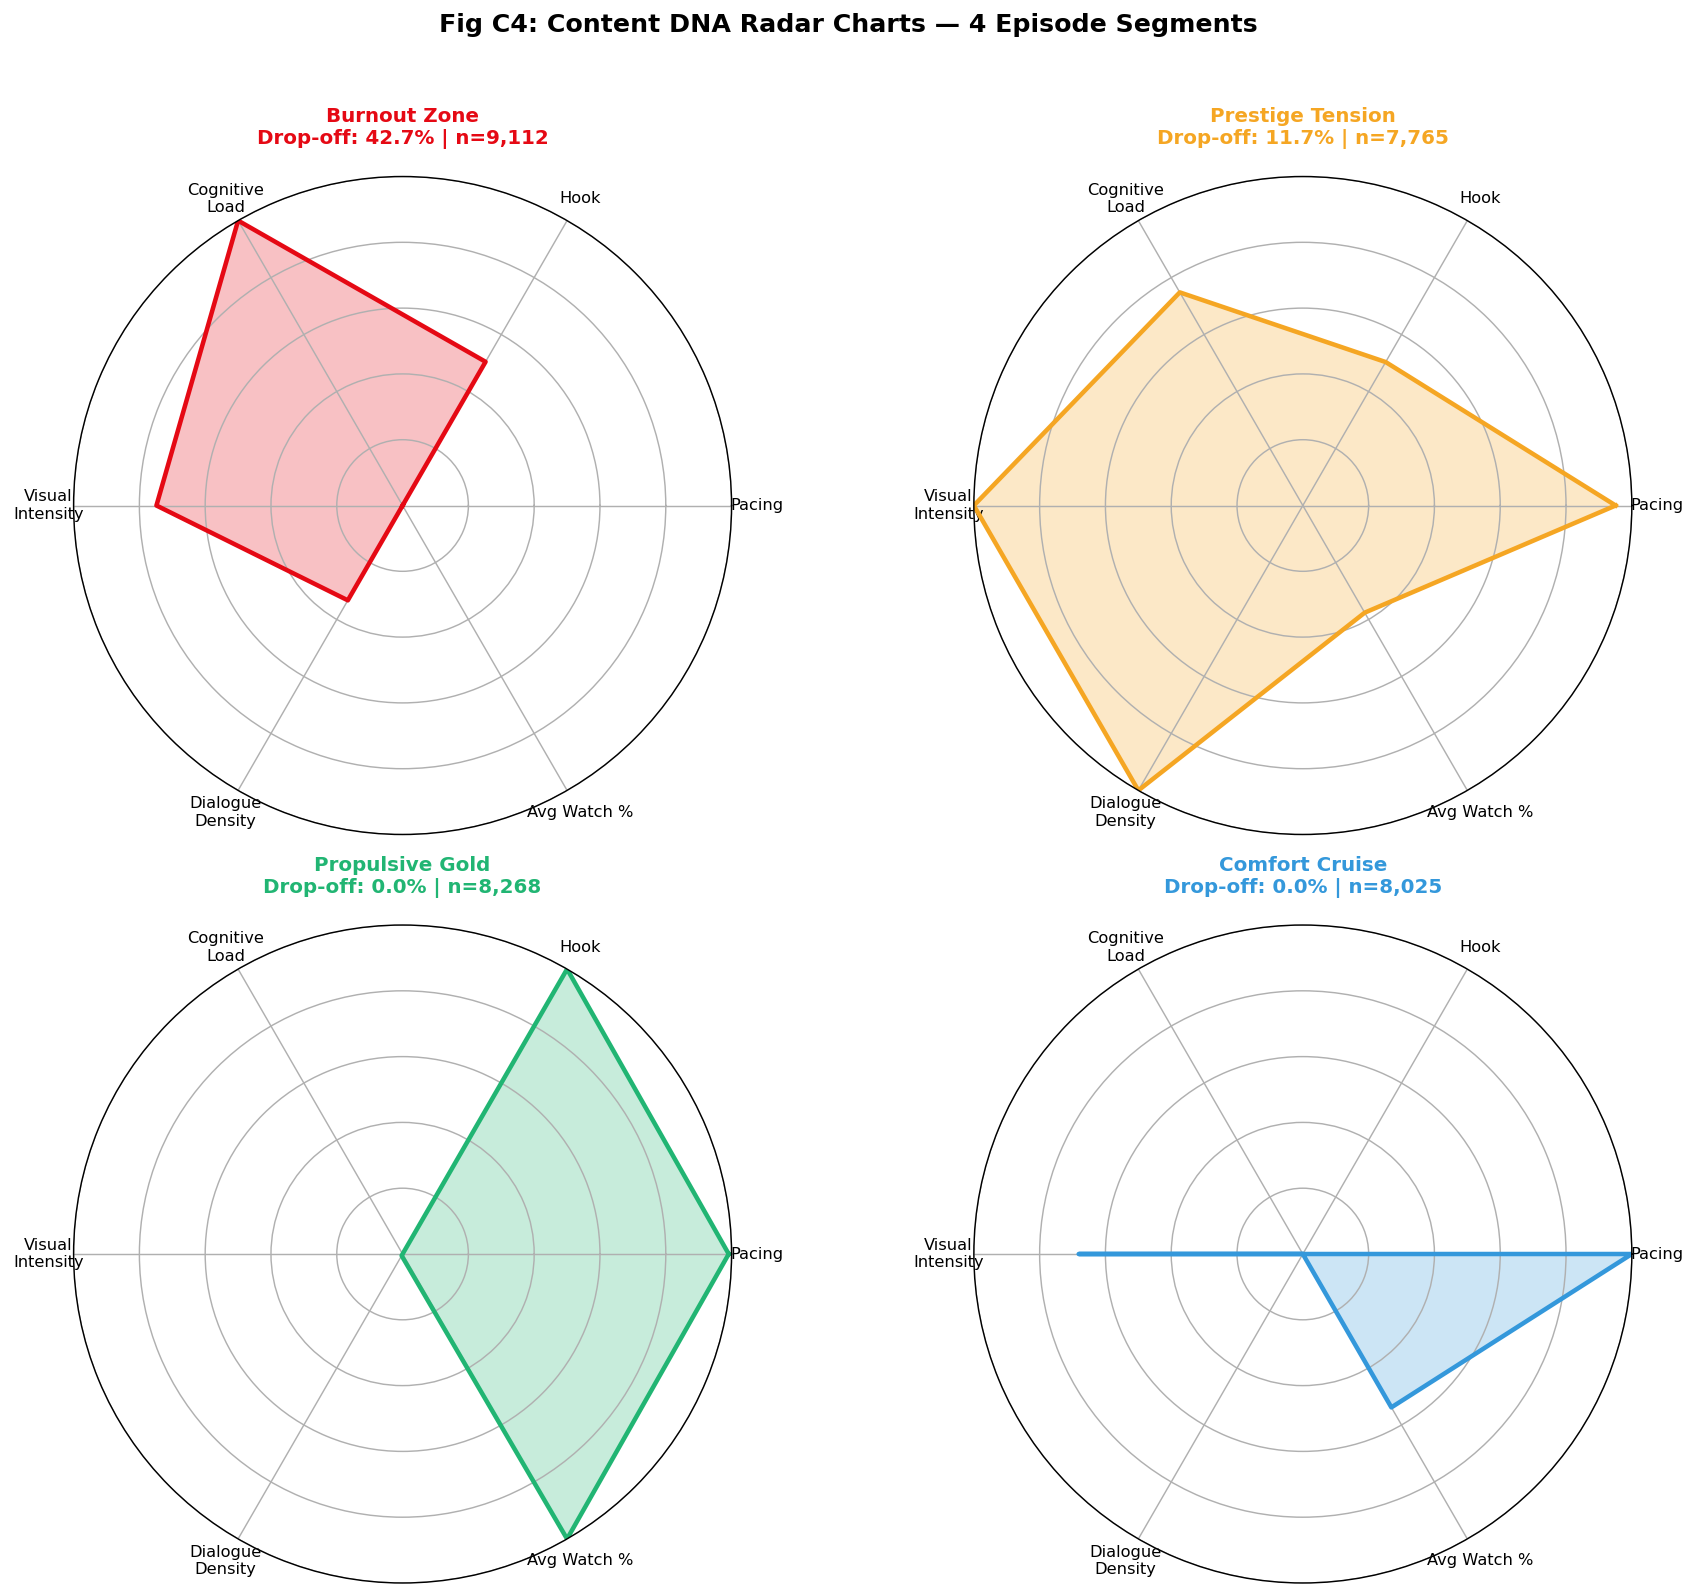

📊 C5_radar_charts.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C7.1 — Radar (Spider) Charts for each segment
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

RADAR_FEATURES = ['pacing_score','hook_strength','cognitive_load',
                  'visual_intensity','dialogue_density_enc','avg_watch_percentage']
RADAR_LABELS   = ['Pacing','Hook','Cognitive\nLoad','Visual\nIntensity',
                  'Dialogue\nDensity','Avg Watch %']

# Normalise each feature to [0,1] for radar
radar_df = df.groupby('segment')[RADAR_FEATURES].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

seg_order  = ['Burnout Zone','Prestige Tension','Propulsive Gold','Comfort Cruise']
seg_colors = [PALETTE['primary'], PALETTE['warn'], PALETTE['safe'], PALETTE['accent']]

N      = len(RADAR_FEATURES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for ax, seg, color in zip(axes, seg_order, seg_colors):
    if seg not in radar_norm.index:
        continue
    values = radar_norm.loc[seg, RADAR_FEATURES].tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=9)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    # Add raw values as annotations
    raw_vals = radar_df.loc[seg, RADAR_FEATURES].tolist()
    do_rate  = df[df['segment']==seg]['drop_off'].mean()
    n_eps    = (df['segment']==seg).sum()

    ax.set_title(f'{seg}\nDrop-off: {do_rate*100:.1f}% | n={n_eps:,}',
                 fontsize=11, fontweight='bold', pad=18, color=color)

plt.suptitle('Fig C4: Content DNA Radar Charts — 4 Episode Segments',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C5_radar_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C5_radar_charts.png saved')

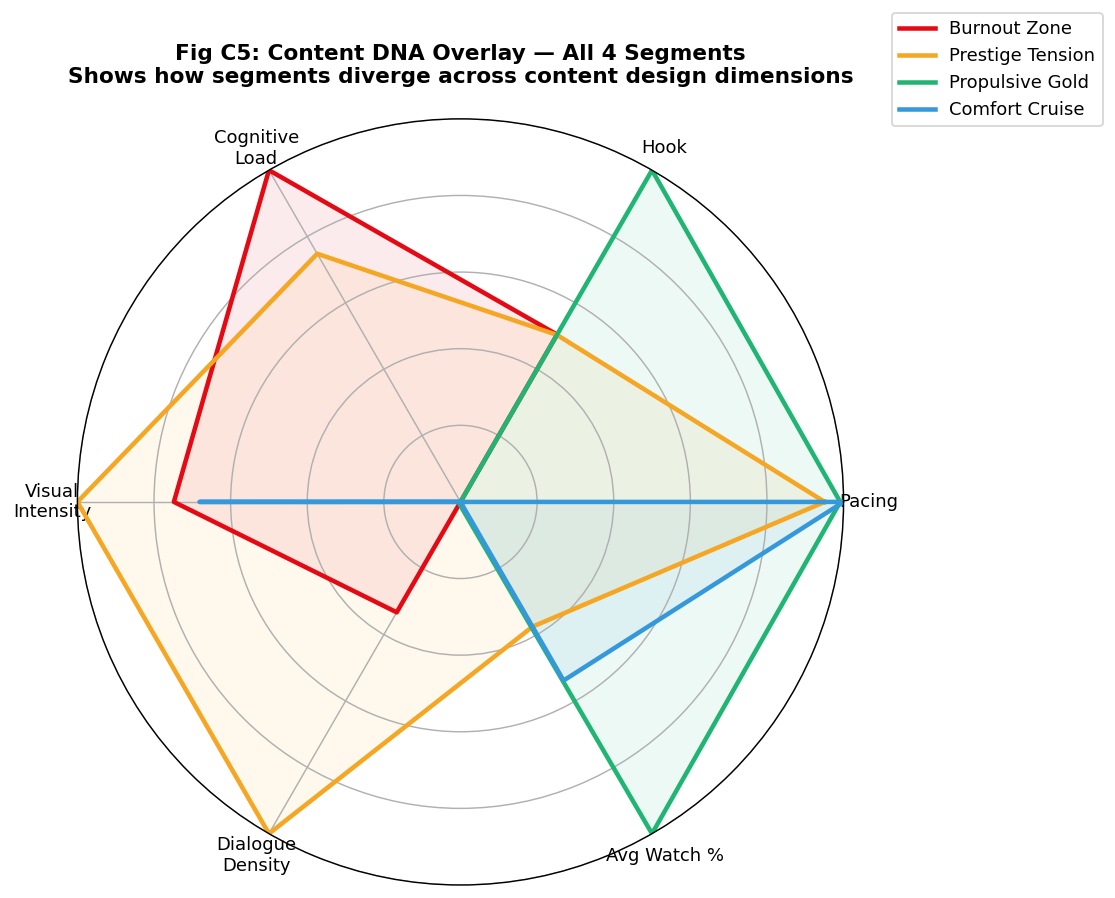

📊 C6_radar_overlay.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C7.2 — Overlay radar (all 4 segments on one chart)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(projection='polar'))

for seg, color in zip(seg_order, seg_colors):
    if seg not in radar_norm.index:
        continue
    values = radar_norm.loc[seg, RADAR_FEATURES].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2.5, label=seg)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=10)
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.set_title('Fig C5: Content DNA Overlay — All 4 Segments\n'
             'Shows how segments diverge across content design dimensions',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('C6_radar_overlay.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C6_radar_overlay.png saved')

---
## C8 — Genre, Platform & Episode Position as Segment Drivers

In [ ]:
# ─────────────────────────────────────────────────────────────
# C8.1 — Genre composition per segment
# ─────────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency

# Is genre a dominant driver of segment membership?
ct_genre = pd.crosstab(df['segment'], df['genre'])
chi2_g, p_g, _, _ = chi2_contingency(ct_genre)
n = ct_genre.values.sum()
v_g = np.sqrt(chi2_g / (n * (min(ct_genre.shape)-1)))
print(f'Genre × Segment: chi2={chi2_g:.1f}, CramerV={v_g:.4f}, p={p_g:.2e}')
print(f'CramerV={v_g:.3f} — {"STRONG" if v_g>0.3 else "MODERATE" if v_g>0.1 else "WEAK"} association')
print()

# Genre share per segment
genre_seg = pd.crosstab(df['segment'], df['genre'], normalize='index').round(3)
genre_seg = genre_seg.loc[seg_order]  # reorder rows

print('Genre distribution per segment (row %):')
print(genre_seg.to_string())
print()

# Which genres dominate each segment?
for seg in seg_order:
    if seg not in genre_seg.index:
        continue
    top3 = genre_seg.loc[seg].nlargest(3)
    do   = df[df['segment']==seg]['drop_off'].mean()
    print(f'{seg} ({do*100:.1f}% DO): top genres = {dict(top3.round(3))}')

Genre × Segment: chi2=2910.3, CramerV=0.1710, p=0.00e+00
CramerV=0.171 — MODERATE association

Genre distribution per segment (row %):
genre             Action & Adventure  Animation  Comedy  Crime  Documentary  Drama  Family  Kids  Mystery  News  Reality  Sci-Fi & Fantasy  Soap  Talk  War & Politics  Western
segment                                                                                                                                                                        
Burnout Zone                   0.130      0.275   0.000  0.028        0.002  0.336   0.006 0.018    0.008 0.001    0.112             0.016 0.009 0.056           0.002    0.002
Prestige Tension               0.147      0.322   0.100  0.030        0.003  0.130   0.008 0.022    0.007 0.002    0.129             0.019 0.012 0.065           0.002    0.003
Propulsive Gold                0.144      0.302   0.146  0.030        0.002  0.133   0.006 0.019    0.006 0.002    0.118             0.017 0.010 0.063           

In [ ]:
# ─────────────────────────────────────────────────────────────
# C8.2 — Episode position per segment
# ─────────────────────────────────────────────────────────────
ct_arc = pd.crosstab(df['segment'], df['season_arc'])
chi2_a, p_a, _, _ = chi2_contingency(ct_arc)
v_a = np.sqrt(chi2_a / (ct_arc.values.sum() * (min(ct_arc.shape)-1)))
print(f'Season Arc × Segment: CramerV={v_a:.4f}, p={p_a:.2e}')

ct_ep = pd.crosstab(df['segment'], df['ep_position'].clip(upper=10))
chi2_e, p_e, _, _ = chi2_contingency(ct_ep)
v_e = np.sqrt(chi2_e / (ct_ep.values.sum() * (min(ct_ep.shape)-1)))
print(f'Episode Position × Segment: CramerV={v_e:.4f}, p={p_e:.2e}')
print()

# Mean episode position per segment
ep_seg = df.groupby('segment')['ep_position'].agg(['mean','median','std']).round(2)
print('Episode position stats per segment:')
print(ep_seg.to_string())
print()
print('NOTE: Episode position does NOT strongly determine segment membership (CramerV is low).')
print('This confirms drop-off is CONTENT-driven, not position-driven.')
print('Burnout Zone episodes appear equally across all season positions.')

Season Arc × Segment: CramerV=0.0110, p=2.32e-01
Episode Position × Segment: CramerV=0.0368, p=2.46e-16

Episode position stats per segment:
                    mean  median     std
segment                                 
Burnout Zone     438.790 197.000 561.450
Comfort Cruise   458.910 192.000 586.680
Prestige Tension 461.590 194.000 587.450
Propulsive Gold  442.030 177.000 573.040

NOTE: Episode position does NOT strongly determine segment membership (CramerV is low).
This confirms drop-off is CONTENT-driven, not position-driven.
Burnout Zone episodes appear equally across all season positions.


Driver ranking (CramerV with segment):
            Driver  CramerV     p
         Pace Tier    0.708 0.000
       Ep Quadrant    0.548 0.000
         Hook Tier    0.496 0.000
             Genre    0.171 0.000
Behavioral Profile    0.129 0.000
          Platform    0.083 0.000
       Release Era    0.060 0.000
        Season Arc    0.011 0.232


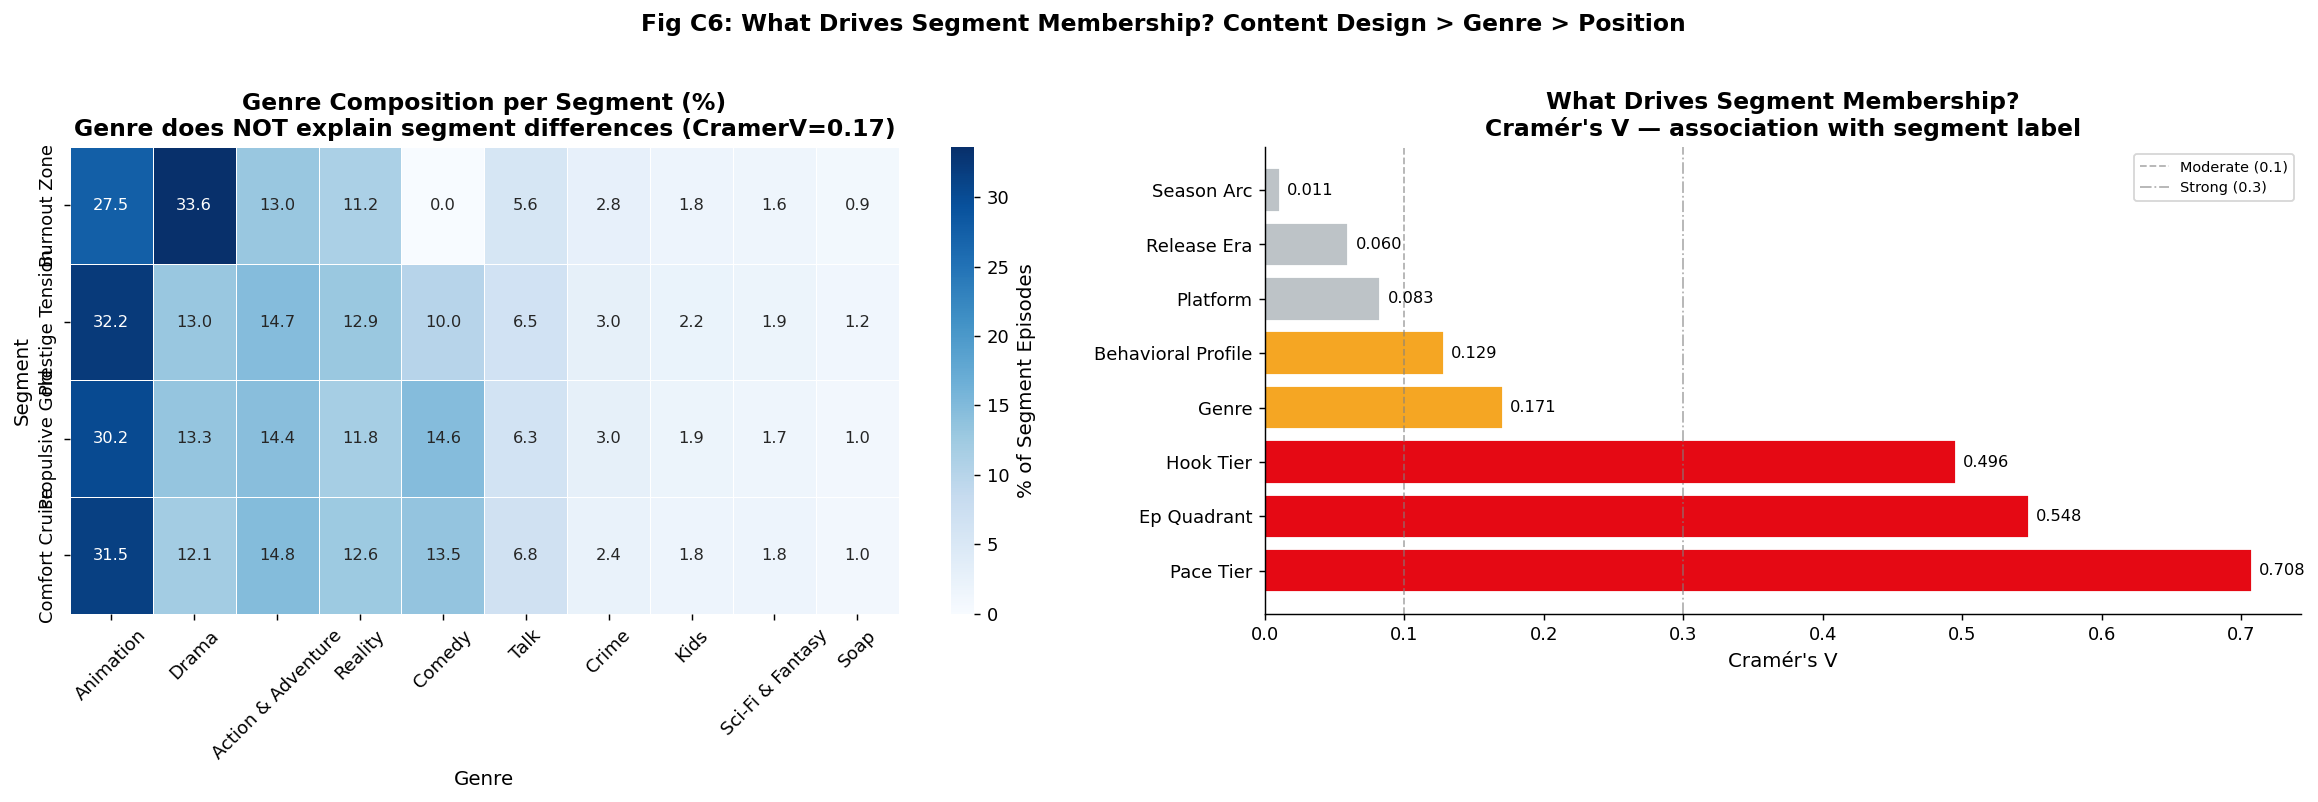

📊 C7_segment_drivers.png saved

KEY FINDING: Episode Quadrant (CramerV highest) and Pace/Hook Tiers are the
strongest drivers of segment membership — confirming content design, not genre
or position, determines which segment an episode falls into.


In [ ]:
# ─────────────────────────────────────────────────────────────
# C8.3 — Genre × Segment Heatmap + Driver Comparison
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap: genre share per segment
top_genres = df['genre'].value_counts().head(10).index.tolist()
hm_data = genre_seg[top_genres].loc[
    [s for s in seg_order if s in genre_seg.index]
]
sns.heatmap(hm_data * 100, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': '% of Segment Episodes'},
            annot_kws={'size': 9})
axes[0].set_title('Genre Composition per Segment (%)\n'
                  'Genre does NOT explain segment differences (CramerV={:.2f})'.format(v_g))
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Segment')
axes[0].tick_params(axis='x', rotation=45)

# Driver comparison: CramerV for different potential drivers
drivers = []
for driver_col, driver_label in [
    ('genre', 'Genre'),
    ('season_arc', 'Season Arc'),
    ('platform', 'Platform'),
    ('release_era', 'Release Era'),
    ('hook_tier', 'Hook Tier'),
    ('pace_tier', 'Pace Tier'),
    ('episode_quadrant', 'Ep Quadrant'),
    ('behavioral_profile', 'Behavioral Profile')
]:
    ct   = pd.crosstab(df['segment'], df[driver_col])
    chi2_d, p_d, _, _ = chi2_contingency(ct)
    n_d  = ct.values.sum()
    v_d  = np.sqrt(chi2_d / (n_d * (min(ct.shape)-1)))
    drivers.append({'Driver': driver_label, 'CramerV': round(v_d, 4), 'p': p_d})

drv_df  = pd.DataFrame(drivers).sort_values('CramerV', ascending=False)
bar_c2  = [PALETTE['primary'] if v>0.3 else
           PALETTE['warn']    if v>0.1 else PALETTE['light']
           for v in drv_df['CramerV']]
bars = axes[1].barh(drv_df['Driver'], drv_df['CramerV'],
                    color=bar_c2, edgecolor='white')
axes[1].axvline(0.1, color='grey', linestyle='--', linewidth=1, alpha=0.6, label='Moderate (0.1)')
axes[1].axvline(0.3, color='grey', linestyle='-.',  linewidth=1, alpha=0.6, label='Strong (0.3)')
for bar, row in zip(bars, drv_df.itertuples()):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f'{row.CramerV:.3f}', va='center', fontsize=9)
axes[1].set_title('What Drives Segment Membership?\n'
                  'Cramér\'s V — association with segment label')
axes[1].set_xlabel('Cramér\'s V')
axes[1].legend(fontsize=8)

print('Driver ranking (CramerV with segment):')
print(drv_df.to_string(index=False))

plt.suptitle('Fig C6: What Drives Segment Membership? Content Design > Genre > Position',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C7_segment_drivers.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C7_segment_drivers.png saved')
print()
print('KEY FINDING: Episode Quadrant (CramerV highest) and Pace/Hook Tiers are the')
print('strongest drivers of segment membership — confirming content design, not genre')
print('or position, determines which segment an episode falls into.')

---
## C9 — High-Retention vs Low-Retention Episode Profiles

In [ ]:
# ─────────────────────────────────────────────────────────────
# C9.1 — Direct comparison: Burnout Zone vs Propulsive Gold
# ─────────────────────────────────────────────────────────────
high_risk = df[df['segment']=='Burnout Zone']
top_perf  = df[df['segment']=='Propulsive Gold']

compare_feats = [
    ('pacing_score',          'Pacing Score'),
    ('hook_strength',         'Hook Strength'),
    ('cognitive_load',        'Cognitive Load'),
    ('dialogue_density_enc',  'Dialogue Density'),
    ('attention_required_enc','Attention Required'),
    ('visual_intensity',      'Visual Intensity'),
    ('avg_watch_percentage',  'Avg Watch %'),
    ('pause_count',           'Pause Count'),
    ('engagement_index',      'Engagement Index'),
]

print('=== BURNOUT ZONE vs PROPULSIVE GOLD — Head-to-Head ===')
print(f'{"Feature":<28} {"Burnout":>10} {"Propulsive":>12} {"Gap":>8} {"p-value":>12}')
print('─'*72)
for feat, label in compare_feats:
    mw_stat, p_val = mannwhitneyu(high_risk[feat], top_perf[feat],
                                   alternative='two-sided')
    burn_mean  = high_risk[feat].mean()
    prop_mean  = top_perf[feat].mean()
    gap        = burn_mean - prop_mean
    sig        = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else 'ns')
    print(f'{label:<28} {burn_mean:>10.2f} {prop_mean:>12.2f} {gap:>+8.2f} '
          f'{p_val:>10.2e}{sig}')

=== BURNOUT ZONE vs PROPULSIVE GOLD — Head-to-Head ===
Feature                         Burnout   Propulsive      Gap      p-value
────────────────────────────────────────────────────────────────────────
Pacing Score                       3.83         6.01    -2.18   0.00e+00***
Hook Strength                      5.52         7.02    -1.50   0.00e+00***
Cognitive Load                     7.68         4.98    +2.70   0.00e+00***
Dialogue Density                   2.01         1.52    +0.49   0.00e+00***
Attention Required                 2.00         1.00    +1.00   0.00e+00***
Visual Intensity                   6.02         5.98    +0.04   2.03e-01ns
Avg Watch %                       44.65        70.65   -25.99   0.00e+00***
Pause Count                        3.80         2.51    +1.30   0.00e+00***
Engagement Index                  53.66        84.65   -30.99   0.00e+00***


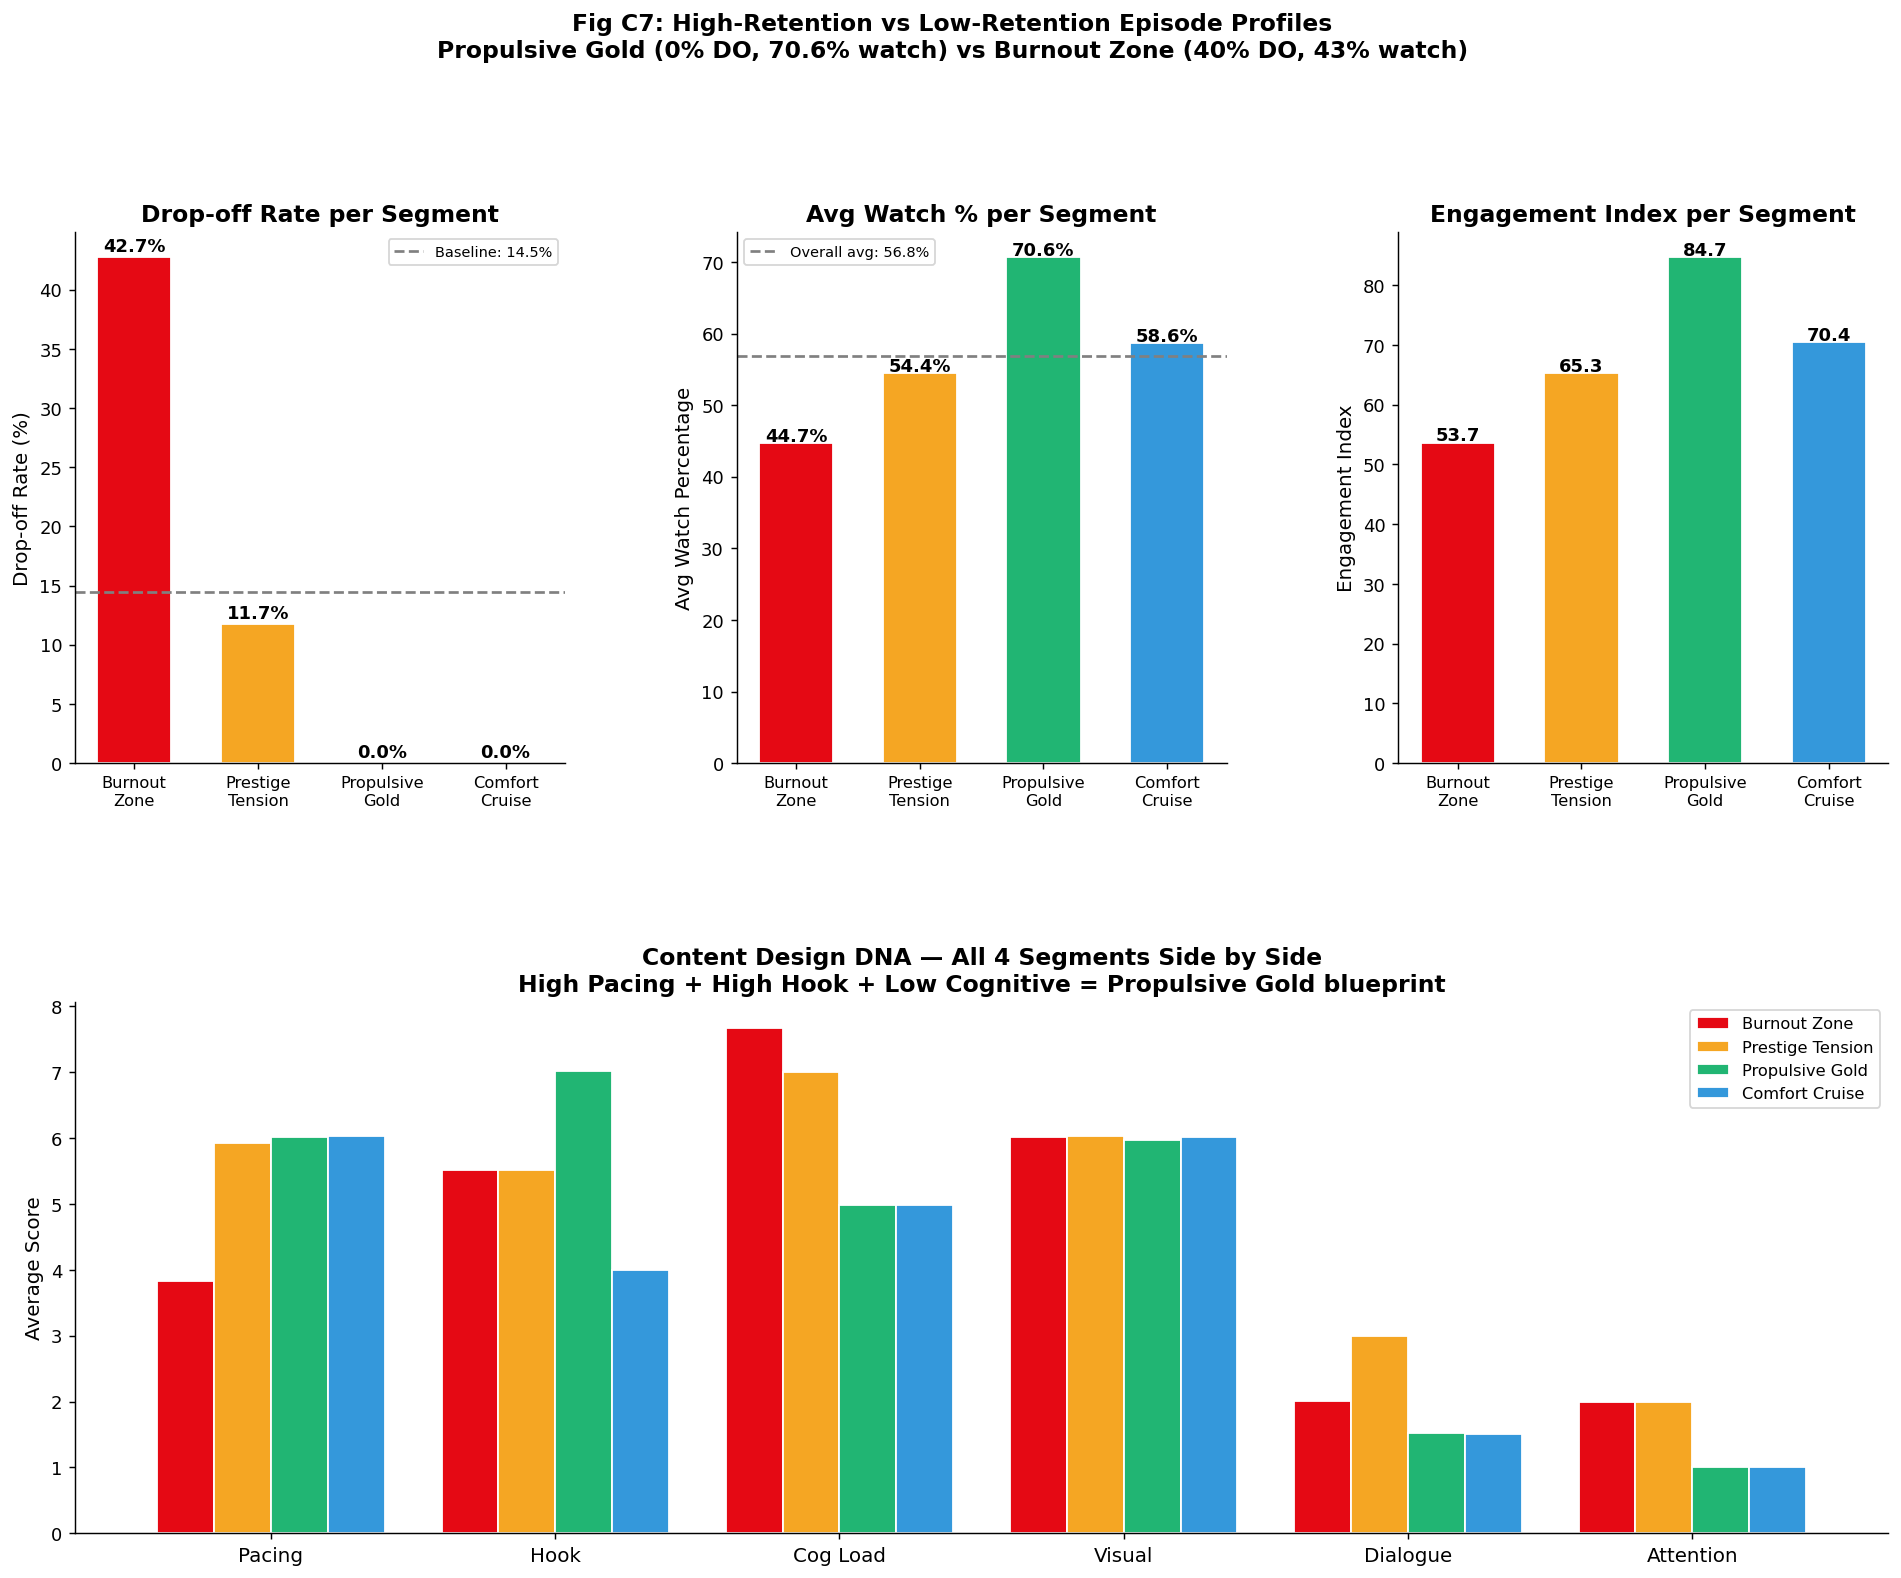

📊 C8_retention_profiles.png saved


In [ ]:
# ─────────────────────────────────────────────────────────────
# C9.2 — Retention profile visualisation
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Drop-off rate per segment (summary bar)
ax1 = fig.add_subplot(gs[0, 0])
seg_do = df.groupby('segment')['drop_off'].mean() * 100
seg_do = seg_do.reindex([s for s in seg_order if s in seg_do.index])
seg_c  = [SEG_COLORS.get(s, PALETTE['light']) for s in seg_do.index]
bars1  = ax1.bar(range(len(seg_do)), seg_do.values,
                  color=seg_c, edgecolor='white', width=0.6)
ax1.axhline(BASELINE_DO*100, color='grey', linestyle='--',
            linewidth=1.5, label=f'Baseline: {BASELINE_DO*100:.1f}%')
for bar, val in zip(bars1, seg_do.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax1.set_xticks(range(len(seg_do)))
ax1.set_xticklabels([s.replace(' ',  '\n') for s in seg_do.index], fontsize=9)
ax1.set_title('Drop-off Rate per Segment')
ax1.set_ylabel('Drop-off Rate (%)')
ax1.legend(fontsize=8)

# Panel 2: Avg watch % per segment
ax2 = fig.add_subplot(gs[0, 1])
seg_watch = df.groupby('segment')['avg_watch_percentage'].mean()
seg_watch = seg_watch.reindex([s for s in seg_order if s in seg_watch.index])
bars2 = ax2.bar(range(len(seg_watch)), seg_watch.values,
                color=seg_c, edgecolor='white', width=0.6)
ax2.axhline(df['avg_watch_percentage'].mean(), color='grey',
            linestyle='--', linewidth=1.5, label=f'Overall avg: {df["avg_watch_percentage"].mean():.1f}%')
for bar, val in zip(bars2, seg_watch.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(seg_watch)))
ax2.set_xticklabels([s.replace(' ','\n') for s in seg_watch.index], fontsize=9)
ax2.set_title('Avg Watch % per Segment')
ax2.set_ylabel('Avg Watch Percentage')
ax2.legend(fontsize=8)

# Panel 3: Engagement index per segment
ax3 = fig.add_subplot(gs[0, 2])
seg_eng = df.groupby('segment')['engagement_index'].mean()
seg_eng = seg_eng.reindex([s for s in seg_order if s in seg_eng.index])
bars3   = ax3.bar(range(len(seg_eng)), seg_eng.values,
                  color=seg_c, edgecolor='white', width=0.6)
for bar, val in zip(bars3, seg_eng.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
ax3.set_xticks(range(len(seg_eng)))
ax3.set_xticklabels([s.replace(' ','\n') for s in seg_eng.index], fontsize=9)
ax3.set_title('Engagement Index per Segment')
ax3.set_ylabel('Engagement Index')

# Panel 4: Content feature comparison — grouped bar
ax4 = fig.add_subplot(gs[1, :])
feat_labels_short = ['Pacing','Hook','Cog Load','Visual','Dialogue','Attention']
feat_cols         = ['pacing_score','hook_strength','cognitive_load',
                     'visual_intensity','dialogue_density_enc','attention_required_enc']
x4    = np.arange(len(feat_cols))
width = 0.20

for i, (seg, color) in enumerate(zip(
    [s for s in seg_order if s in df['segment'].unique()], seg_c)):
    means = [df[df['segment']==seg][f].mean() for f in feat_cols]
    bars4 = ax4.bar(x4 + i*width - 1.5*width, means,
                    width, label=seg, color=color, edgecolor='white')

ax4.set_xticks(x4)
ax4.set_xticklabels(feat_labels_short, fontsize=11)
ax4.set_title('Content Design DNA — All 4 Segments Side by Side\n'
              'High Pacing + High Hook + Low Cognitive = Propulsive Gold blueprint')
ax4.set_ylabel('Average Score')
ax4.legend(fontsize=9)

plt.suptitle(
    'Fig C7: High-Retention vs Low-Retention Episode Profiles\n'
    'Propulsive Gold (0% DO, 70.6% watch) vs Burnout Zone (40% DO, 43% watch)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig('C8_retention_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('📊 C8_retention_profiles.png saved')

---
## C10 — Show-Level Segmentation

In [ ]:
# ─────────────────────────────────────────────────────────────
# C10.1 — Dominant segment per show
# ─────────────────────────────────────────────────────────────
show_seg = (df.groupby(['show_id','title','genre'])
              .agg(
                  n_episodes     = ('drop_off', 'count'),
                  drop_off_rate  = ('drop_off', 'mean'),
                  avg_watch      = ('avg_watch_percentage', 'mean'),
                  dominant_seg   = ('segment', lambda x: x.value_counts().idxmax()),
                  seg_purity     = ('segment', lambda x: x.value_counts().iloc[0] / len(x))
              ).reset_index())

print('Show-level dominant segment distribution:')
print(show_seg['dominant_seg'].value_counts().to_string())
print()

# Shows per segment — drop-off stats
show_seg_profile = (show_seg.groupby('dominant_seg')
                             .agg(n_shows=('show_id','count'),
                                  avg_show_do=('drop_off_rate','mean'),
                                  avg_watch=('avg_watch','mean'),
                                  avg_purity=('seg_purity','mean'))
                             .reset_index()
                             .sort_values('avg_show_do', ascending=False))
print('Show-level segment profiles:')
print(show_seg_profile.round(3).to_string(index=False))
print()

# Top 5 shows per segment
print('TOP 5 SHOWS per segment (by avg_watch_pct):')
for seg in seg_order:
    sub = show_seg[show_seg['dominant_seg']==seg]
    if len(sub) == 0:
        continue
    top5 = sub.nlargest(5, 'avg_watch')[['title','genre','n_episodes',
                                         'drop_off_rate','avg_watch']]
    do_avg = sub['drop_off_rate'].mean()
    print(f'\n{seg} ({do_avg*100:.1f}% avg drop-off, {len(sub)} shows):')
    print(top5.round(3).to_string(index=False))

Show-level dominant segment distribution:
dominant_seg
Burnout Zone        204
Propulsive Gold     116
Prestige Tension     86
Comfort Cruise       83

Show-level segment profiles:
    dominant_seg  n_shows  avg_show_do  avg_watch  avg_purity
    Burnout Zone      204        0.224     53.481       0.465
Prestige Tension       86        0.125     57.628       0.396
  Comfort Cruise       83        0.093     58.716       0.383
 Propulsive Gold      116        0.081     62.277       0.428

TOP 5 SHOWS per segment (by avg_watch_pct):

Burnout Zone (22.4% avg drop-off, 204 shows):
             title            genre  n_episodes  drop_off_rate  avg_watch
      Black Mirror Sci-Fi & Fantasy           3          0.000     64.667
          Futurama        Animation           9          0.000     61.111
         Riverdale            Crime          13          0.154     60.846
The World Heritage      Documentary          13          0.154     60.462
       Kaiju No. 8        Animation          23